#**Menghubungkan google colab dengan google drive**

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Mengimpor Library yang dibutuhkan**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


#**Mengimpor Dataset**

In [ ]:
df = pd.read_csv ('/content/drive/MyDrive/datacsv/DATASET (FIX).csv')

print (df)

        ID                      produk      harga    kategori  rating  \
0      1.0             baju polos navy    50000.0     pakaian     4.5   
1      2.0            celana jeans Lea    80000.0     pakaian     4.2   
2      3.0      sepatu sneakers ngreen   120000.0     pakaian     4.8   
3      4.0                   laptop hp  8000000.0  elektronik     4.7   
4      5.0              mouse wireless    30000.0  elektronik     4.0   
..     ...                         ...        ...         ...     ...   
145  146.0                 topi fedora    60000.0   aksesoris     4.8   
146    NaN                         NaN        NaN         NaN     NaN   
147  148.0    tas ransel vintage navy     55000.0   aksesoris     4.9   
148  149.0  speaker portable bluetooth   270000.0  elektronik     4.7   
149  150.0              kacamata retro    95000.0   aksesoris     4.5   

     persediaan  diskon (%) lokasi pengiriman  jumlah pembelian  
0          15.0        10.0           jakarta            

#**Cek Data**

In [ ]:
df.head()

,ID,produk,harga,kategori,rating,persediaan,diskon (%),lokasi pengiriman,jumlah pembelian
0,1.0,baju polos navy,50000.0,pakaian,4.5,15.0,10.0,jakarta,20.0
1,2.0,celana jeans Lea,80000.0,pakaian,4.2,10.0,5.0,surabaya,15.0
2,3.0,sepatu sneakers ngreen,120000.0,pakaian,4.8,70.0,0.0,bandung,10.0
3,4.0,laptop hp,8000000.0,elektronik,4.7,3.0,15.0,jakarta,5.0
4,5.0,mouse wireless,30000.0,elektronik,4.0,20.0,10.0,surabaya,25.0


In [ ]:
df.dtypes

ID                   float64
produk                object
harga                float64
kategori              object
rating               float64
persediaan           float64
diskon (%)           float64
lokasi pengiriman     object
jumlah pembelian     float64
dtype: object

#**Menghapus Kolom ID**

In [ ]:
df.drop('ID',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   produk             82 non-null     object 
 1   harga              82 non-null     float64
 2   kategori           82 non-null     object 
 3   rating             82 non-null     float64
 4   persediaan         82 non-null     float64
 5   diskon (%)         82 non-null     float64
 6   lokasi pengiriman  82 non-null     object 
 7   jumlah pembelian   82 non-null     float64
dtypes: float64(5), object(3)
memory usage: 9.5+ KB


In [ ]:
df.describe()

,harga,rating,persediaan,diskon (%),jumlah pembelian
count,8.200000e+01,82.000000,82.000000,82.000000,82.000000
mean,2.563780e+05,4.562195,14.109756,5.853659,15.560976
std,9.041830e+05,0.259934,11.633292,4.018850,7.442118
min,8.000000e+03,3.800000,2.000000,0.000000,3.000000
25%,4.500000e+04,4.400000,8.000000,5.000000,10.000000
50%,8.000000e+04,4.600000,11.000000,5.000000,14.500000
75%,1.425000e+05,4.700000,15.000000,10.000000,20.000000
max,8.000000e+06,4.900000,70.000000,15.000000,40.000000


#**Cek Data yang mempunyai duplikat dan nilai Null**

In [ ]:
df.isnull().sum()

produk               0
harga                0
kategori             0
rating               0
persediaan           0
diskon (%)           0
lokasi pengiriman    0
jumlah pembelian     0
dtype: int64

In [ ]:
df = df.dropna()
df = df.dropna(axis=1)

In [ ]:
df

,produk,harga,kategori,rating,persediaan,diskon (%),lokasi pengiriman,jumlah pembelian
0,baju polos navy,50000.0,pakaian,4.5,15.0,10.0,jakarta,20.0
1,celana jeans Lea,80000.0,pakaian,4.2,10.0,5.0,surabaya,15.0
2,sepatu sneakers ngreen,120000.0,pakaian,4.8,70.0,0.0,bandung,10.0
3,laptop hp,8000000.0,elektronik,4.7,3.0,15.0,jakarta,5.0
4,mouse wireless,30000.0,elektronik,4.0,20.0,10.0,surabaya,25.0
...,...,...,...,...,...,...,...,...
142,gaun pesta,1200000.0,pakaian,4.7,6.0,5.0,bandung,7.0
145,topi fedora,60000.0,aksesoris,4.8,13.0,5.0,bandung,15.0
147,tas ransel vintage navy,55000.0,aksesoris,4.9,12.0,10.0,surabaya,20.0
148,speaker portable bluetooth,270000.0,elektronik,4.7,8.0,5.0,bandung,11.0


In [ ]:
df.duplicated().sum()

0

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Buat DataFrame baru dengan nama baru
of_df = df.copy()

# Penanganan nilai null
# Misalnya, kita akan mengisi nilai null dengan rata-rata untuk setiap fitur numerik
imputer = SimpleImputer(strategy='mean')
numerical_features = ['harga', 'rating', 'persediaan', 'diskon (%)', 'jumlah pembelian']
of_df[numerical_features] = imputer.fit_transform(of_df[numerical_features])

# Scailing fitur-fitur numerik
scaler = StandardScaler()
of_df[numerical_features] = scaler.fit_transform(of_df[numerical_features])

# Tampilkan DataFrame baru setelah penanganan nilai null dan scailing
print(of_df)


                         produk     harga    kategori    rating  persediaan  \
0               baju polos navy -0.229653     pakaian -0.240746    0.076996   
1              celana jeans Lea -0.196269     pakaian -1.401989   -0.355449   
2        sepatu sneakers ngreen -0.151758     pakaian  0.920498    4.833901   
3                     laptop hp  8.616923  elektronik  0.533417   -0.960874   
4                mouse wireless -0.251908  elektronik -2.176151    0.509442   
..                          ...       ...         ...       ...         ...   
142                  gaun pesta  1.050041     pakaian  0.533417   -0.701406   
145                 topi fedora -0.218525   aksesoris  0.920498   -0.095982   
147    tas ransel vintage navy  -0.224089   aksesoris  1.307579   -0.182471   
148  speaker portable bluetooth  0.015158  elektronik  0.533417   -0.528428   
149              kacamata retro -0.179578   aksesoris -0.240746   -0.355449   

     diskon (%) lokasi pengiriman  jumlah pembelian

#**Pengkategorian Data**

In [ ]:
categorical_column = df.select_dtypes(include=['object']).columns.tolist()
categorical_column

['produk', 'kategori', 'lokasi pengiriman']

In [ ]:
numerical = df.select_dtypes(include=['float64']).columns.tolist()
numerical

['harga', 'rating', 'persediaan', 'diskon (%)', 'jumlah pembelian']

In [ ]:
# Menghitung jumlah produk berdasarkan lokasi pengiriman
shipping_counts = df['lokasi pengiriman'].value_counts()

# Menghitung jumlah produk berdasarkan kategori
category_counts = df['kategori'].value_counts()

In [ ]:
shipping_counts

lokasi pengiriman
bandung     39
jakarta     25
surabaya    18
Name: count, dtype: int64

In [ ]:
category_counts

kategori
aksesoris     36
elektronik    27
pakaian       19
Name: count, dtype: int64

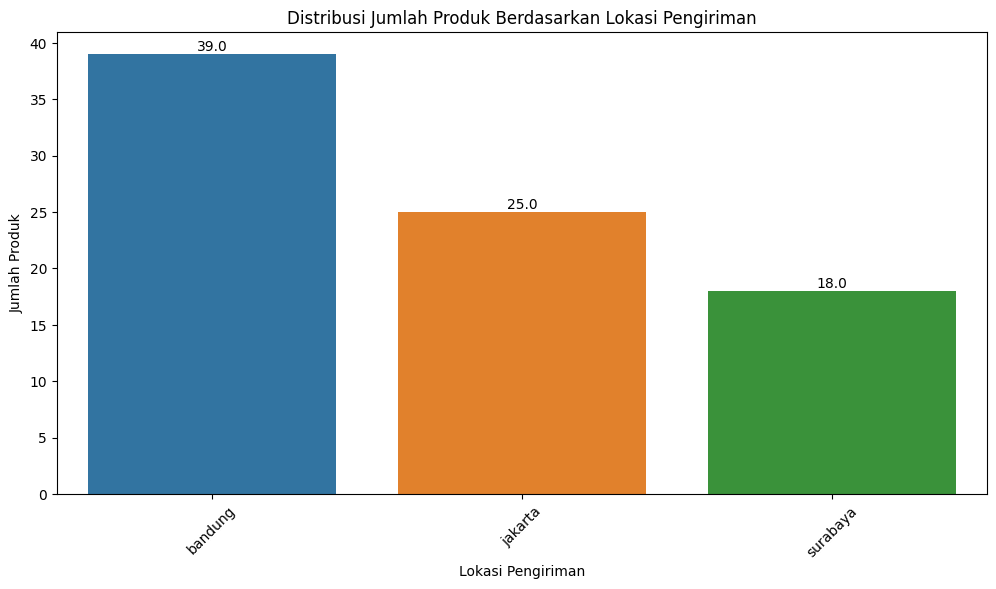

In [ ]:
# Visualisasi distribusi jumlah produk berdasarkan lokasi pengiriman
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=shipping_counts.index, y=shipping_counts.values, hue=shipping_counts.index, dodge=False)

for p in ax.patches:
    height = p.get_height()
    if height != 0:
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.title('Distribusi Jumlah Produk Berdasarkan Lokasi Pengiriman')
plt.xlabel('Lokasi Pengiriman')
plt.ylabel('Jumlah Produk')
plt.xticks(rotation=45)
plt.show()

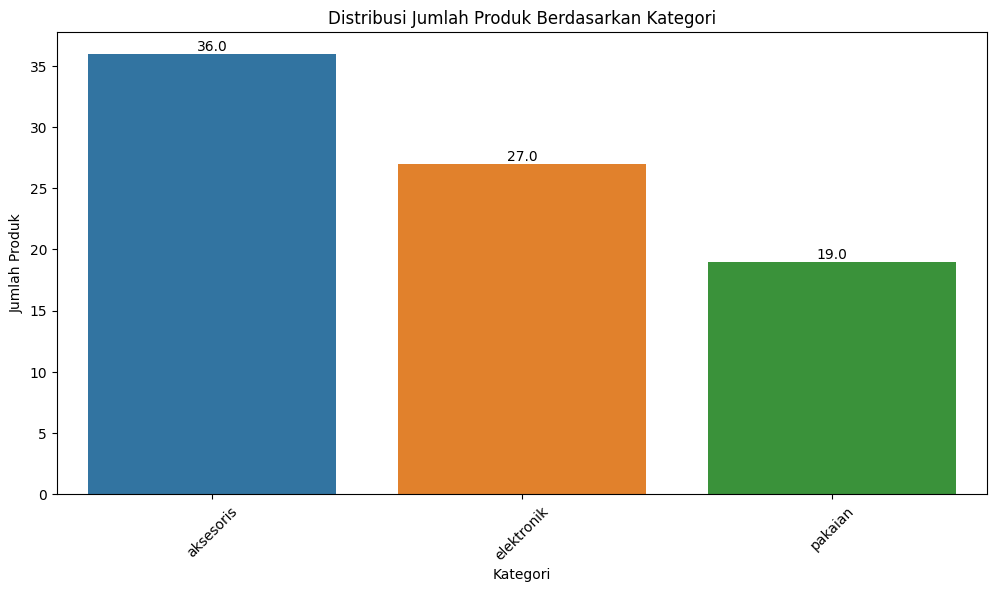

In [ ]:
# Visualisasi distribusi jumlah produk berdasarkan kategori
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, dodge=False)

for p in ax.patches:
    height = p.get_height()
    if height != 0:
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.title('Distribusi Jumlah Produk Berdasarkan Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Produk')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Definisikan fungsi untuk mengkategorikan rating
def categorize_rating(rating):
    if rating < 4.0:
        return 'Kelas 1: Buruk'
    elif 4.0 <= rating < 4.5:
        return 'Kelas 2: Cukup'
    elif 4.5 <= rating < 4.8:
        return 'Kelas 3: Baik'
    else:
        return 'Kelas 4: Sangat Baik'

# Buat kolom baru untuk kelas rating berdasarkan rating
df['Kelas Rating'] = df['rating'].apply(categorize_rating)

df

,produk,harga,kategori,rating,persediaan,diskon (%),lokasi pengiriman,jumlah pembelian,Kelas Rating
0,baju polos navy,50000.0,pakaian,4.5,15.0,10.0,jakarta,20.0,Kelas 3: Baik
1,celana jeans Lea,80000.0,pakaian,4.2,10.0,5.0,surabaya,15.0,Kelas 2: Cukup
2,sepatu sneakers ngreen,120000.0,pakaian,4.8,70.0,0.0,bandung,10.0,Kelas 4: Sangat Baik
3,laptop hp,8000000.0,elektronik,4.7,3.0,15.0,jakarta,5.0,Kelas 3: Baik
4,mouse wireless,30000.0,elektronik,4.0,20.0,10.0,surabaya,25.0,Kelas 2: Cukup
...,...,...,...,...,...,...,...,...,...
142,gaun pesta,1200000.0,pakaian,4.7,6.0,5.0,bandung,7.0,Kelas 3: Baik
145,topi fedora,60000.0,aksesoris,4.8,13.0,5.0,bandung,15.0,Kelas 4: Sangat Baik
147,tas ransel vintage navy,55000.0,aksesoris,4.9,12.0,10.0,surabaya,20.0,Kelas 4: Sangat Baik
148,speaker portable bluetooth,270000.0,elektronik,4.7,8.0,5.0,bandung,11.0,Kelas 3: Baik


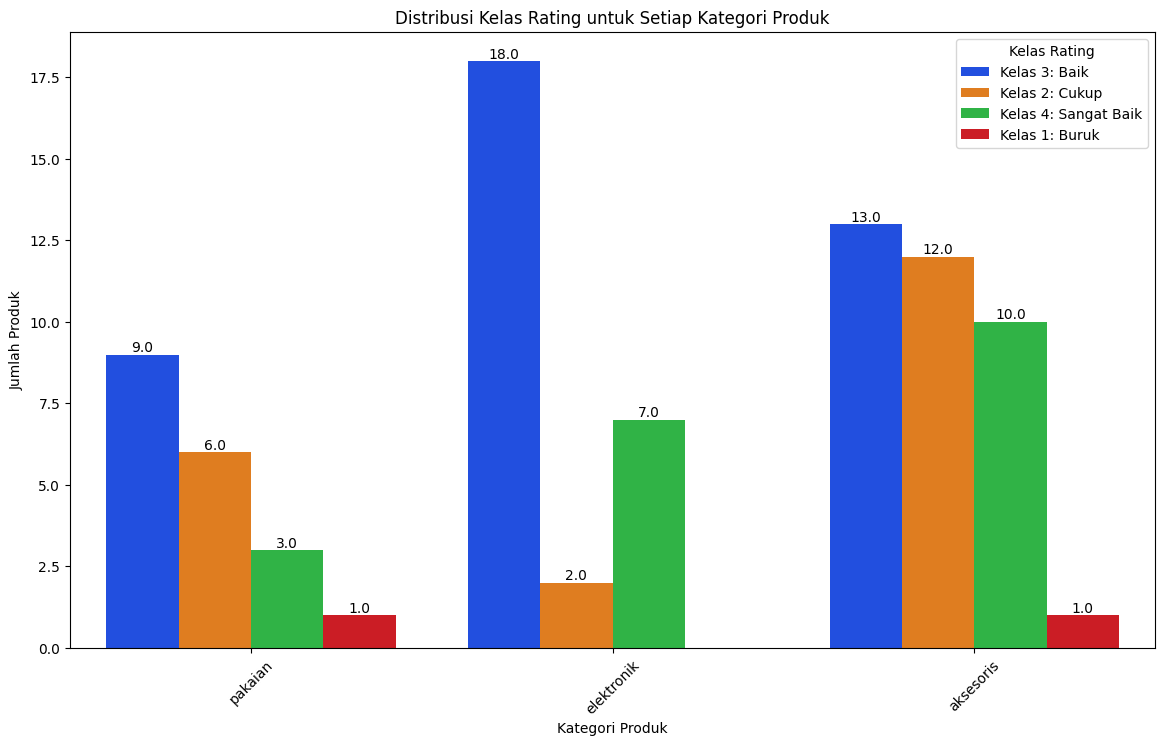

In [ ]:
# Visualisasi distribusi kelas rating untuk setiap kategori produk
plt.figure(figsize=(14, 8))
ax = sns.countplot(x='kategori', hue='Kelas Rating', data=df, palette='bright')

total_data = len(df)
for p in ax.patches:
    height = p.get_height()
    if height != 0:
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.title('Distribusi Kelas Rating untuk Setiap Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Produk')
plt.legend(title='Kelas Rating')
plt.xticks(rotation=45)

plt.show()

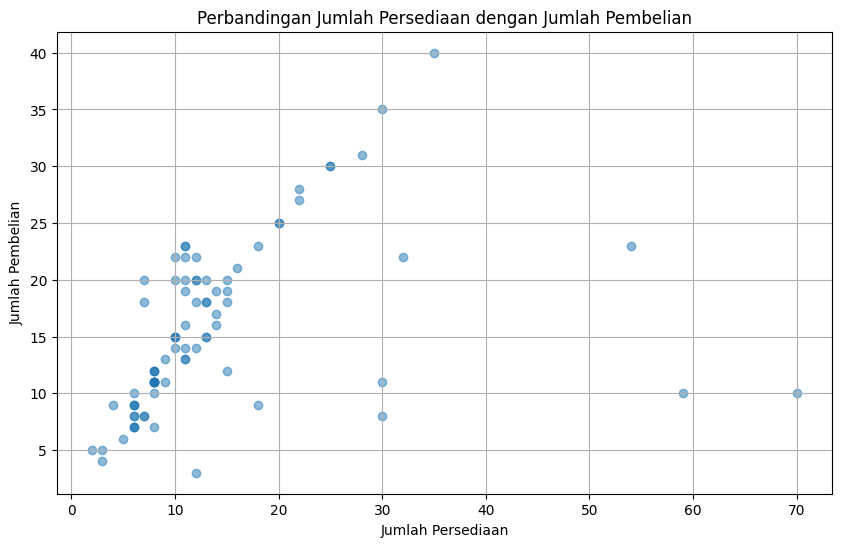

In [ ]:
# Membandingkan jumlah persediaan dengan jumlah pembelian
plt.figure(figsize=(10, 6))
plt.scatter(df['persediaan'], df['jumlah pembelian'], alpha=0.5)
plt.title('Perbandingan Jumlah Persediaan dengan Jumlah Pembelian')
plt.xlabel('Jumlah Persediaan')
plt.ylabel('Jumlah Pembelian')
plt.grid(True)
plt.show()

In [ ]:
# Menghitung rata-rata diskon untuk setiap kategori produk
avg_discount_by_category = df.groupby('kategori')['diskon (%)'].mean().reset_index()

<ipython-input-153-39c3d7248079>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='kategori', y='diskon (%)', data=avg_discount_by_category, palette='husl')


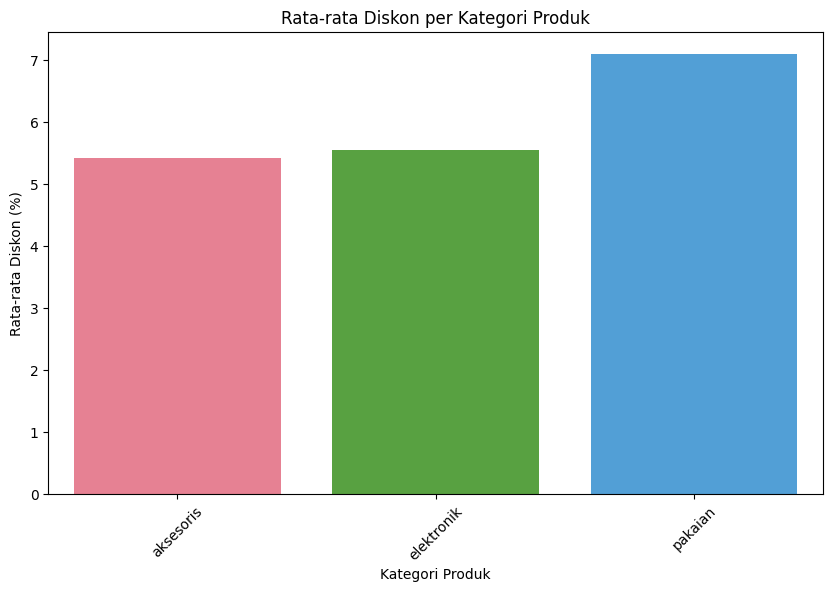

In [ ]:
# Membuat plot dengan palet warna yang berbeda
plt.figure(figsize=(10, 6))
sns.barplot(x='kategori', y='diskon (%)', data=avg_discount_by_category, palette='husl')
plt.title('Rata-rata Diskon per Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Rata-rata Diskon (%)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Buat DataFrame baru dengan nama baru
new_df = df.copy()

# Hitung tingkat penjualan untuk setiap produk (contoh menggunakan kolom 'jumlah pembelian')
new_df['Total Pembelian'] = new_df.groupby('produk')['jumlah pembelian'].transform('sum')

# Tetapkan kriteria (misalnya, produk populer adalah yang memiliki total pembelian di atas rata-rata)
popular_threshold = new_df['Total Pembelian'].mean()

# Kategorisasikan produk berdasarkan kriteria
new_df['Kategori Penjualan'] = new_df['Total Pembelian'].apply(lambda x: 'Populer' if x > popular_threshold else 'Tidak Populer')

# Tampilkan DataFrame baru dengan kolom kategori baru
new_df


,produk,harga,kategori,rating,persediaan,diskon (%),lokasi pengiriman,jumlah pembelian,Kelas Rating,Total Pembelian,Kategori Penjualan
0,baju polos navy,50000.0,pakaian,4.5,15.0,10.0,jakarta,20.0,Kelas 3: Baik,20.0,Populer
1,celana jeans Lea,80000.0,pakaian,4.2,10.0,5.0,surabaya,15.0,Kelas 2: Cukup,15.0,Tidak Populer
2,sepatu sneakers ngreen,120000.0,pakaian,4.8,70.0,0.0,bandung,10.0,Kelas 4: Sangat Baik,10.0,Tidak Populer
3,laptop hp,8000000.0,elektronik,4.7,3.0,15.0,jakarta,5.0,Kelas 3: Baik,5.0,Tidak Populer
4,mouse wireless,30000.0,elektronik,4.0,20.0,10.0,surabaya,25.0,Kelas 2: Cukup,25.0,Populer
...,...,...,...,...,...,...,...,...,...,...,...
142,gaun pesta,1200000.0,pakaian,4.7,6.0,5.0,bandung,7.0,Kelas 3: Baik,7.0,Tidak Populer
145,topi fedora,60000.0,aksesoris,4.8,13.0,5.0,bandung,15.0,Kelas 4: Sangat Baik,35.0,Populer
147,tas ransel vintage navy,55000.0,aksesoris,4.9,12.0,10.0,surabaya,20.0,Kelas 4: Sangat Baik,20.0,Populer
148,speaker portable bluetooth,270000.0,elektronik,4.7,8.0,5.0,bandung,11.0,Kelas 3: Baik,22.0,Populer


In [ ]:
# Buat DataFrame baru dengan nama baru
next_df = df.copy()

# Tentukan rentang harga untuk setiap kategori
harga_bins = [0, 50000, 100000, float('inf')]
harga_labels = ['Murah', 'Sedang', 'Mahal']

# Klasifikasikan produk berdasarkan harga
next_df['Kategori Harga'] = pd.cut(next_df['harga'], bins=harga_bins, labels=harga_labels, right=False)

# Tampilkan DataFrame baru dengan kolom kategori harga
next_df


,produk,harga,kategori,rating,persediaan,diskon (%),lokasi pengiriman,jumlah pembelian,Kelas Rating,Kategori Harga
0,baju polos navy,50000.0,pakaian,4.5,15.0,10.0,jakarta,20.0,Kelas 3: Baik,Sedang
1,celana jeans Lea,80000.0,pakaian,4.2,10.0,5.0,surabaya,15.0,Kelas 2: Cukup,Sedang
2,sepatu sneakers ngreen,120000.0,pakaian,4.8,70.0,0.0,bandung,10.0,Kelas 4: Sangat Baik,Mahal
3,laptop hp,8000000.0,elektronik,4.7,3.0,15.0,jakarta,5.0,Kelas 3: Baik,Mahal
4,mouse wireless,30000.0,elektronik,4.0,20.0,10.0,surabaya,25.0,Kelas 2: Cukup,Murah
...,...,...,...,...,...,...,...,...,...,...
142,gaun pesta,1200000.0,pakaian,4.7,6.0,5.0,bandung,7.0,Kelas 3: Baik,Mahal
145,topi fedora,60000.0,aksesoris,4.8,13.0,5.0,bandung,15.0,Kelas 4: Sangat Baik,Sedang
147,tas ransel vintage navy,55000.0,aksesoris,4.9,12.0,10.0,surabaya,20.0,Kelas 4: Sangat Baik,Sedang
148,speaker portable bluetooth,270000.0,elektronik,4.7,8.0,5.0,bandung,11.0,Kelas 3: Baik,Mahal


#**Data Splitting**

In [ ]:
# Memilih fitur-fitur yang relevan
fitur = ['harga', 'rating', 'persediaan', 'diskon (%)', 'jumlah pembelian']

# Memisahkan fitur-fitur dan target
X = df[fitur]
y = df['kategori']

In [ ]:
# Melakukan encoding jika diperlukan (misalnya jika terdapat kategori yang bersifat nominal)
X_encoded = pd.get_dummies(X)


In [ ]:
# Memisahkan data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=40)

In [ ]:
# Standarisasi atau normalisasi data training dan testing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#**Model**

#**Random Forest**

In [ ]:
# Inisialisasi model Random Forest
classifier = RandomForestClassifier(random_state=42)

# Latih model menggunakan data latih
classifier.fit(X_train, y_train)

# Lakukan prediksi menggunakan data uji
y_pred = classifier.predict(X_test)

# Evaluasi performa model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Cetak confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Cetak classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8
Confusion Matrix:
[[9 0 1]
 [1 7 0]
 [3 0 4]]
Classification Report:
              precision    recall  f1-score   support

   aksesoris       0.69      0.90      0.78        10
  elektronik       1.00      0.88      0.93         8
     pakaian       0.80      0.57      0.67         7

    accuracy                           0.80        25
   macro avg       0.83      0.78      0.79        25
weighted avg       0.82      0.80      0.80        25



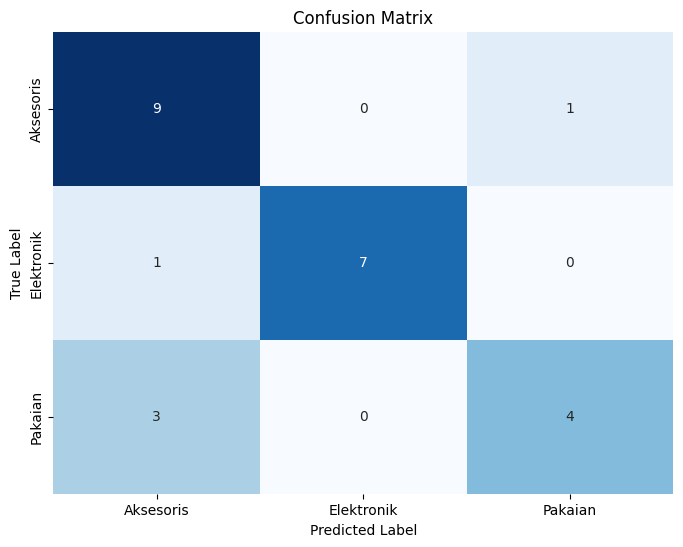

In [ ]:
# Menghitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Membuat visualisasi heatmap dari confusion matrix dengan label kelas yang sesuai
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Aksesoris', 'Elektronik', 'Pakaian'], yticklabels=['Aksesoris', 'Elektronik', 'Pakaian'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
